# Baseline CNN Model

Project:
Explainable AI-Powered Pneumonia Diagnosis & Clinical Decision Support System

Objectives:

- Build a benchmark CNN model
- Handle class imbalance
- Evaluate classification performance
- Establish baseline metrics for comparison

In [1]:
import os
import numpy as np
import pandas as pd

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

DATASET_PATH = "/content/drive/MyDrive/archive (6)/chest_xray/chest_xray"

print("Dataset Exists:", os.path.exists(DATASET_PATH))
print("Train Classes:", os.listdir(os.path.join(DATASET_PATH, "train")))

Dataset Exists: True
Train Classes: ['.DS_Store', 'NORMAL', 'PNEUMONIA']


In [4]:

DATASET_PATH = "/content/drive/MyDrive/archive (6)/chest_xray/chest_xray"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [6]:

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="grayscale"
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="grayscale"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
    color_mode="grayscale"
)

Found 5242 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [8]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [9]:


labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(1.9357459379615953), 1: np.float64(0.6741255144032922)}


In [10]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,1)
    ),

    MaxPooling2D(2,2),

    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(2,2),

    BatchNormalization(),

    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(2,2),

    BatchNormalization(),

    GlobalAveragePooling2D(),

Dense(
    128,
    activation="relu"
),

Dropout(0.5),

Dense(
    1,
    activation="sigmoid"
)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

## CNN Architecture Optimization

Initial architecture used a Flatten layer, resulting in approximately 11.1 million trainable parameters.

To reduce model complexity and improve generalization, Flatten was replaced with GlobalAveragePooling2D.

Benefits:

- Reduced parameters from 11.1M to 110K
- Lower overfitting risk
- Faster training
- Improved computational efficiency

Final architecture uses GlobalAveragePooling2D as the feature aggregation layer.

In [13]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [15]:
checkpoint = ModelCheckpoint(
    "best_baseline_cnn.keras",
    monitor="val_loss",
    save_best_only=True
)

In [16]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 1523s 9s/step - accuracy: 0.8712 - loss: 0.2860 - val_accuracy: 0.5000 - val_loss: 3.4204
Epoch 2/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 55s 334ms/step - accuracy: 0.9048 - loss: 0.2301 - val_accuracy: 0.5000 - val_loss: 1.6973
Epoch 3/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 54s 329ms/step - accuracy: 0.9227 - loss: 0.1974 - val_accuracy: 0.5000 - val_loss: 6.3610
Epoch 4/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 54s 330ms/step - accuracy: 0.9334 - loss: 0.1608 - val_accuracy: 0.5000 - val_loss: 2.6674
Epoch 5/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 55s 334ms/step - accuracy: 0.9361 - loss: 0.1634 - val_accuracy: 0.5000 - val_loss: 2.7524
Epoch 6/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 56s 339ms/step - accuracy: 0.9424 - loss: 0.1493 - val_accuracy: 0.5625 - val_loss: 2.3928
Epoch 7/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 56s 343ms/step - accuracy: 0.9542 - loss: 0.1236 - val_accuracy: 0.5000 - val_loss: 4.4286


In [17]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "best_baseline_cnn.keras"
)

In [18]:
test_loss, test_acc = best_model.evaluate(
    test_generator
)

print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 223s 12s/step - accuracy: 0.6250 - loss: 1.1922
Test Accuracy: 0.625


In [19]:
import numpy as np

pred_probs = best_model.predict(
    test_generator
)

preds = (pred_probs > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_generator.classes,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       234
           1       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_generator.classes,
    preds
)

print(cm)

[[  0 234]
 [  0 390]]


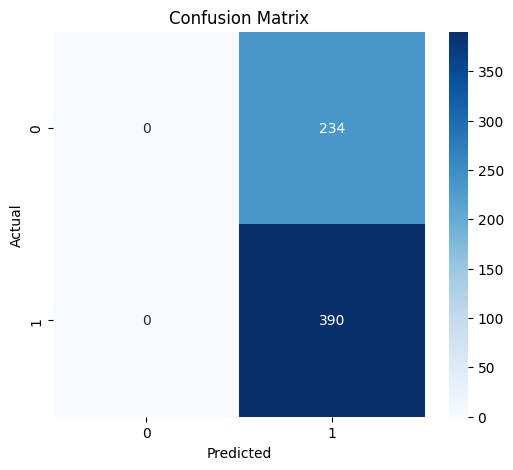

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

# Baseline CNN Results

## Test Performance

| Metric | Value |
|----------|----------|
| Accuracy | 62.5% |

## Observations

The baseline CNN achieved an accuracy of 62.5%.

Confusion matrix analysis revealed that the model predicted all test samples as the majority class (PNEUMONIA).

## Interpretation

The model failed to effectively distinguish between NORMAL and PNEUMONIA classes despite the use of class weighting.

Possible causes include:

- Significant class imbalance
- Limited model capacity
- Insufficient feature extraction capability
- Small validation dataset

## Conclusion

The baseline CNN established a benchmark but demonstrated poor class discrimination.

More advanced transfer learning architectures are required to extract clinically meaningful radiographic features.